## Problem 1

### Autoencoder Overview
An autoencoder consists of two parts:

- Encoder: compresses data into a latent representation
- Decoder: reconstructs the input

It is trained to reconstruct an original input with an objective of minimizing reconstruction error.

### Gan Overview
A GAN consistes of two competing networks:

- Generator: creates fake samples
- Discriminator: tries to distinguish real from fake

It is trained to generate content via a minimax game. 

### Comparison
The training goal of an autoencoder is to reconstruct an input, whereas the training goal for a GAN is to fool the discriminator. 

Autoencoders optimize using a single objective, GANs as a two-player game.

Autoencoders are typically easier and more stable to train because they optimize a single reconstruction loss, whereas GANs can suffer from instability issues such as mode collapse and non-convergence.

A vanilla autoencoder is not generative in the probabilistic sense.Variational Autoencoders (VAEs) introduce a probabilistic latent space to enable sampling, but often generate blurrier images compared to GANs.

Autoencoders learn a latent representation deterministically by encoding input data. GANs sample latent vectors from a predefined prior distribution (e.g., Gaussian) and learn to map them to realistic data.

### Typical Use Cases
Autoencoders
- Nonlinear dimensionality reduction
- Denoising
- Anomaly detection
- Feature learning / representation learning
- Data compression
- Unsupervised pretraining (historically)

GANs
- High-fidelity image generation
- Deepfake / face synthesis
- Super-resolution
- Image-to-image translation
- Data augmentation
- Text-to-image generation

### References
- Goodfellow, I., Bengio, Y., & Courville, A. (2016). Deep Learning. MIT Press. Chapters 14 and 20.
- Foster, David (2023). Generative Deep Learning, 2nd edition, O’Reilly Media, Inc.


## Problem 2

### Setup

In [2]:
%matplotlib inline
import matplotlib.pyplot as plt
plt.rcParams["figure.dpi"] = 72
import numpy as np
import os
import sys

import torch
from torch import nn, optim
import torchvision
print(f'PyTorch version= {torch.__version__}')
print(f'torchvision version= {torchvision.__version__}')
print(f'CUDA available= {torch.cuda.is_available()}')

# Set the GPU to device 0
Device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

PyTorch version= 2.10.0
torchvision version= 0.25.0
CUDA available= False


The following code is modified to:
- Add a wgan_output path for comparison
- Use the smaller MNIST dataset

In [4]:
from torch.utils.data import DataLoader, ConcatDataset, Subset
import torchvision.datasets as dset
import torchvision.transforms as vtransforms
import torchvision.utils as vutils


# store images for debug  and info
DBG_FOLDER_GAN= 'output/gan_output'
DBG_FOLDER_WGAN= 'output/wgan_output'

IMG_SIZE= 28  # image size, square
BATCH_SIZE= 4096

# labels to learn
# FMNIST_LABELS = [1, 2, 3, 4, 5]
FMNIST_LABELS = [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]


# concat both train and test
train_ds = dset.MNIST(root = "../../datasets", download=False, train=True,
                             transform=vtransforms.Compose([
                                 vtransforms.Resize([IMG_SIZE,IMG_SIZE], antialias=True),
                                 vtransforms.ToTensor(),
                                 vtransforms.Normalize((0.5,), (0.5,)) ]))
test_ds = dset.MNIST(root = "../../datasets", download=False, train=False,
                            transform=vtransforms.Compose([
                                vtransforms.Resize([IMG_SIZE,IMG_SIZE], antialias=True),
                                vtransforms.ToTensor(),
                                vtransforms.Normalize((0.5,), (0.5,)) ]))
ix1 = [_ for _, target in enumerate(train_ds.targets) if target in FMNIST_LABELS]
ix2 = [_ for _, target in enumerate(test_ds.targets) if target in FMNIST_LABELS]
gan_ds_ = ConcatDataset([Subset(train_ds,ix1),Subset(test_ds,ix2)])

Dloader_gan = DataLoader(gan_ds_, batch_size=BATCH_SIZE, shuffle=True,
                         num_workers=8, pin_memory=True, prefetch_factor=4, persistent_workers=True)

In [5]:
# Compute H, W for image size _H, _W
def findConv2dOutShape(_H, _W, _nn, pool=2):
    H = np.floor((_H+2*_nn.padding[0]-_nn.dilation[0]*(_nn.kernel_size[0]-1)-1)/_nn.stride[0]+1)
    W = np.floor((_W+2*_nn.padding[1]-_nn.dilation[1]*(_nn.kernel_size[1]-1)-1)/_nn.stride[1]+1)
    if pool:
        H, W = H/pool, W/pool
    return int(H), int(W)

def findConvTranspose2d(_H, _W, _nn, pool=2):
    H = (_H-1)*_nn.stride[0]-2*_nn.padding[0]+_nn.dilation[0]*(_nn.kernel_size[0]-1)+_nn.output_padding[0]+1
    W = (_W-1)*_nn.stride[1]-2*_nn.padding[1]+_nn.dilation[1]*(_nn.kernel_size[1]-1)+_nn.output_padding[1]+1
    if pool:
        H, W = H/pool, W/pool
    return int(H), int(W)

In [6]:
IMG_CHANNEL= 1
D_HIDDEN= 32

class Discriminator(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(

            nn.Conv2d(IMG_CHANNEL, D_HIDDEN, 4, 2, 1, bias=False),
            nn.LeakyReLU(0.2),

            nn.Conv2d(D_HIDDEN, 2*D_HIDDEN, 4, 2, 1, bias=False),
            nn.BatchNorm2d(2*D_HIDDEN),
            nn.LeakyReLU(0.2),

            nn.Conv2d(2*D_HIDDEN, 4*D_HIDDEN, 4, 2, 2, bias=False),
            nn.BatchNorm2d(4*D_HIDDEN),
            nn.LeakyReLU(0.2),

            nn.Conv2d(4*D_HIDDEN, 1, 4, 2, 0, bias=False),
            nn.Sigmoid()
        )
    def forward(self, _input):
        return self.net(_input).view(-1, 1).squeeze(1)

# Check the network layers
print(Discriminator())

Discriminator(
  (net): Sequential(
    (0): Conv2d(1, 32, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (1): LeakyReLU(negative_slope=0.2)
    (2): Conv2d(32, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (3): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (4): LeakyReLU(negative_slope=0.2)
    (5): Conv2d(64, 128, kernel_size=(4, 4), stride=(2, 2), padding=(2, 2), bias=False)
    (6): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (7): LeakyReLU(negative_slope=0.2)
    (8): Conv2d(128, 1, kernel_size=(4, 4), stride=(2, 2), bias=False)
    (9): Sigmoid()
  )
)


### WGAN Discriminator
We create the WGANDiscriminator which is the same as the GAN discriminator, but with the sigmoid removed. Removing the sigmoid changes the output from $(0,1)$ to $(-\infty,\infty)$ so, rather than a probability, we have any real number as an output which is necessary for a WGAN.

In [7]:
class WGANDiscriminator(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(

            nn.Conv2d(IMG_CHANNEL, D_HIDDEN, 4, 2, 1, bias=False),
            nn.LeakyReLU(0.2),

            nn.Conv2d(D_HIDDEN, 2*D_HIDDEN, 4, 2, 1, bias=False),
            nn.BatchNorm2d(2*D_HIDDEN),
            nn.LeakyReLU(0.2),

            nn.Conv2d(2*D_HIDDEN, 4*D_HIDDEN, 4, 2, 2, bias=False),
            nn.BatchNorm2d(4*D_HIDDEN),
            nn.LeakyReLU(0.2),

            nn.Conv2d(4*D_HIDDEN, 1, 4, 2, 0, bias=False),
            # nn.Sigmoid() -- Remove the Sigmoid
        )
    def forward(self, _input):
        return self.net(_input).view(-1, 1).squeeze(1)

    # def forward(self, x):
    #     return self.net(x).view(-1)
    
# Check the network layers
print(WGANDiscriminator())

WGANDiscriminator(
  (net): Sequential(
    (0): Conv2d(1, 32, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (1): LeakyReLU(negative_slope=0.2)
    (2): Conv2d(32, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (3): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (4): LeakyReLU(negative_slope=0.2)
    (5): Conv2d(64, 128, kernel_size=(4, 4), stride=(2, 2), padding=(2, 2), bias=False)
    (6): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (7): LeakyReLU(negative_slope=0.2)
    (8): Conv2d(128, 1, kernel_size=(4, 4), stride=(2, 2), bias=False)
  )
)


In [8]:
# Check the NN configuration
print(findConv2dOutShape(IMG_SIZE, IMG_SIZE, nn.Conv2d(IMG_CHANNEL, D_HIDDEN, 4, 2, 1), pool=0))
print(findConv2dOutShape(14, 14, nn.Conv2d(D_HIDDEN, 2*D_HIDDEN, 4, 2, 1), pool=0))
print(findConv2dOutShape(7, 7, nn.Conv2d(2*D_HIDDEN, 4*D_HIDDEN, 4, 2, 2), pool=0))
print(findConv2dOutShape(4, 4, nn.Conv2d(4*D_HIDDEN, 1, 4, 2, 0), pool=0))

(14, 14)
(7, 7)
(4, 4)
(1, 1)


In [9]:
G_HIDDEN= 32
Z_DIM= 128  # latent space dimension

class Generator(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(

            nn.ConvTranspose2d(Z_DIM, 4*G_HIDDEN, 4, 1, 0, bias=False),
            nn.BatchNorm2d(4*G_HIDDEN),
            nn.ReLU(),

            nn.ConvTranspose2d(4*G_HIDDEN, 2*G_HIDDEN, 4, 1, 0, bias=False),
            nn.BatchNorm2d(2*G_HIDDEN),
            nn.ReLU(),

            nn.ConvTranspose2d(2*G_HIDDEN, G_HIDDEN, 4, 2, 1, bias=False),
            nn.BatchNorm2d(G_HIDDEN),
            nn.ReLU(),

            nn.ConvTranspose2d(G_HIDDEN, IMG_CHANNEL, 4, 2, 1, bias=False),
            nn.Tanh()
        )
    def forward(self, _input):
        return self.net(_input)

# Check the network layers
print(Generator())

Generator(
  (net): Sequential(
    (0): ConvTranspose2d(128, 128, kernel_size=(4, 4), stride=(1, 1), bias=False)
    (1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): ConvTranspose2d(128, 64, kernel_size=(4, 4), stride=(1, 1), bias=False)
    (4): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU()
    (6): ConvTranspose2d(64, 32, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (7): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (8): ReLU()
    (9): ConvTranspose2d(32, 1, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (10): Tanh()
  )
)


In [10]:
# Learning the real and fake - reminder this is not a classification problem
import os

class GAN():
    def __init__(self, epochs=20, eta=0.001, batch_size=1024, dbg_folder=DBG_FOLDER_GAN, info=False, savemodel=False):
        self.epochs, self.eta, self.B = epochs, eta, batch_size
        self.dbg_folder, self.info, self.savemodel = dbg_folder, info, savemodel
        self.criterion = nn.BCELoss()
        self.netD, self.netG, self.optimizerD, self.optimizerG = None, None, None, None
        self.LossDReal, self.LossDFake, self.LossG = None, None, None
        self.LabelReal = 1
        self.LabelFake = 0

    @classmethod
    # Initialize conv layers with N(0,0.02), batch norm layers N(1,0.02) and 0 bias
    def init_weights(cls, _m):
        if isinstance(_m, nn.Conv2d) or isinstance(_m, nn.ConvTranspose2d):
            torch.nn.init.normal_(_m.weight, mean=0.0, std=0.02)
        if isinstance(_m, nn.BatchNorm2d):
            torch.nn.init.normal_(_m.weight, mean=1.0, std=0.02)
            _m.bias.data.fill_(0.0)

    def initDG(self):
        self.netD = Discriminator().to(Device)
        self.netG = Generator().to(Device)
        # Optimizers
        self.optimizerD = optim.Adam(self.netD.parameters(), lr=self.eta, betas=(0.5, 0.999))
        self.optimizerG = optim.Adam(self.netG.parameters(), lr=self.eta, betas=(0.5, 0.999))
    
    def execD(self, _x_real, _real_label, _fake_label):
        self.netD.zero_grad()
        y_real = self.netD(_x_real)
        loss_D_real = self.criterion(y_real, _real_label)
        loss_D_real.backward()

        z_noise = torch.randn(_x_real.size(0), Z_DIM, 1, 1, device=Device)
        x_fake = self.netG(z_noise)
        y_fake = self.netD(x_fake.detach())
        loss_D_fake = self.criterion(y_fake, _fake_label)
        loss_D_fake.backward()
        self.optimizerD.step()
        return x_fake, loss_D_real, loss_D_fake
    
    def execG(self, _x_real, _real_label, _x_fake):
        self.netG.zero_grad()
        y_fake_r = self.netD(_x_fake)
        loss_G = self.criterion(y_fake_r, _real_label)
        loss_G.backward()
        self.optimizerG.step()
        return loss_G

    def fit(self, _train_dl):
        os.makedirs(self.dbg_folder, exist_ok=True)
        self.initDG()
        self.netD.apply(GAN.init_weights)
        self.netG.apply(GAN.init_weights)

        # Same noise sample to generate the sample fake
        viz_noise = torch.randn(self.B, Z_DIM, 1, 1, device=Device)

        self.LossDReal, self.LossDFake, self.LossG = [], [], []

        for e in range(self.epochs):
            lossDr, lossDf, lossG = [], [], []
            for i, data in enumerate(_train_dl):
                x_real = data[0].to(Device, non_blocking=True)
                real_label = torch.full((x_real.size(0),), self.LabelReal, dtype=torch.float32, device=Device)
                fake_label = torch.full((x_real.size(0),), self.LabelFake, dtype=torch.float32, device=Device)

                x_fake, loss_D_real, loss_D_fake = self.execD(x_real, real_label, fake_label)
                loss_G = self.execG(x_real, real_label, x_fake)

                if self.info:
                    sys.stderr.write("\r{:03d}/{:3d} | LossDr: {:6.3f} | lossDf: {:6.3f} | lossG: {:6.3f}".format(
                        e+1, self.epochs, loss_D_real.mean().item(), loss_D_fake.mean().item(), loss_G.mean().item()))
                    sys.stderr.flush()

                    if i == 0:
                        with torch.no_grad():
                            viz_sample = self.netG(viz_noise)
                            # output of the generator is Tanh()
                            vutils.save_image(vutils.make_grid(0.5-0.5*viz_sample[:32], nrow=4),
                                              f'{self.dbg_folder}/fake_samples_{e}.png', normalize=True)

                lossDr += [loss_D_real.mean().item()]  # check if the loss is shape 1 vector
                lossDf += [loss_D_fake.mean().item()]  # check if the loss is shape 1 vector
                lossG += [loss_G.mean().item()]  # check if the loss is shape 1 vector

            self.LossDReal += [(np.array(lossDr).mean(), np.array(lossDr).std())]
            self.LossDFake += [(np.array(lossDf).mean(), np.array(lossDf).std())]
            self.LossG += [(np.array(lossG).mean(), np.array(lossG).std())]
    
            if self.savemodel:
                torch.save(self.netG.state_dict(), f'{self.dbg_folder}/netG_{e}.pth')
                torch.save(self.netD.state_dict(), f'{self.dbg_folder}/netD_{e}.pth')

### WGAN Class

We create the WGAN class which:
- Uses our WGANDiscriminator 
- Updates LabelReal and LabelFake to 1 and -1, respectively.
- Updates the loss function
- Changes the optimizer to RMSProp per the Arjovsky 2017 paper
- Updates the critic to run a few more times than the generator
- Takes a variable clip-weight (we test with 0.01, 0.05, and 0.10 below)

In [11]:
class WGAN():
    def __init__(self, epochs=20, eta=0.001, batch_size=1024, dbg_folder=DBG_FOLDER_WGAN, info=False, savemodel=False, n_critic=5, clip_weight=0.01):
        self.epochs, self.eta, self.B = epochs, eta, batch_size
        self.dbg_folder, self.info, self.savemodel = dbg_folder, info, savemodel
        self.criterion = nn.BCELoss()
        self.netD, self.netG, self.optimizerD, self.optimizerG = None, None, None, None
        self.LossDReal, self.LossDFake, self.LossG = None, None, None
        self.LabelReal = +1
        self.LabelFake = -1
        self.n_critic = n_critic
        self.clip_weight = clip_weight

    @classmethod
    # Initialize conv layers with N(0,0.02), batch norm layers N(1,0.02) and 0 bias
    def init_weights(cls, _m):
        if isinstance(_m, nn.Conv2d) or isinstance(_m, nn.ConvTranspose2d):
            torch.nn.init.normal_(_m.weight, mean=0.0, std=0.02)
        if isinstance(_m, nn.BatchNorm2d):
            torch.nn.init.normal_(_m.weight, mean=1.0, std=0.02)
            _m.bias.data.fill_(0.0)

    def initDG(self):
        self.netD = WGANDiscriminator().to(Device)
        self.netG = Generator().to(Device)
        # Optimizers
        self.optimizerD = optim.RMSprop(self.netD.parameters(), lr=self.eta)
        self.optimizerG = optim.RMSprop(self.netG.parameters(), lr=self.eta)
    
    def execD(self, _x_real, _real_label, _fake_label):
        self.netD.zero_grad()
        y_real = self.netD(_x_real)

        z_noise = torch.randn(_x_real.size(0), Z_DIM, 1, 1, device=Device)
        x_fake = self.netG(z_noise)
        y_fake = self.netD(x_fake.detach())

        loss_D_real = -y_real.mean()
        loss_D_fake =  y_fake.mean()
        loss_D = loss_D_real + loss_D_fake
        loss_D.backward()
        self.optimizerD.step()

        for p in self.netD.parameters():
            p.data.clamp_(-self.clip_weight, +self.clip_weight)

        return x_fake, loss_D_real, loss_D_fake
    
    def execG(self, _x_real, _real_label, _x_fake):
        self.netG.zero_grad()
        y_fake_r = self.netD(_x_fake)
        loss_G = -y_fake_r.mean()
        loss_G.backward()
        self.optimizerG.step()
        return loss_G

    def fit(self, _train_dl):
        os.makedirs(self.dbg_folder, exist_ok=True)
        self.initDG()
        self.netD.apply(GAN.init_weights)
        self.netG.apply(GAN.init_weights)

        # Same noise sample to generate the sample fake
        viz_noise = torch.randn(self.B, Z_DIM, 1, 1, device=Device)

        self.LossDReal, self.LossDFake, self.LossG = [], [], []

        for e in range(self.epochs):
            lossDr, lossDf, lossG = [], [], []
            for i, data in enumerate(_train_dl):
                x_real = data[0].to(Device, non_blocking=True)
                real_label = torch.full((x_real.size(0),), self.LabelReal, dtype=torch.float32, device=Device)
                fake_label = torch.full((x_real.size(0),), self.LabelFake, dtype=torch.float32, device=Device)

                for _ in range(self.n_critic):
                    x_fake, loss_D_real, loss_D_fake = self.execD(x_real, real_label, fake_label)

                loss_G = self.execG(x_real, real_label, x_fake)

                if self.info:
                    sys.stderr.write("\r{:03d}/{:3d} | LossDr: {:6.3f} | lossDf: {:6.3f} | lossG: {:6.3f}".format(
                        e+1, self.epochs, loss_D_real.mean().item(), loss_D_fake.mean().item(), loss_G.mean().item()))
                    sys.stderr.flush()

                    if i == 0:
                        with torch.no_grad():
                            viz_sample = self.netG(viz_noise)
                            # output of the generator is Tanh()
                            vutils.save_image(vutils.make_grid(0.5-0.5*viz_sample[:32], nrow=4),
                                              f'{self.dbg_folder}/wgan_fake_samples_{e}.png', normalize=True)

                lossDr += [loss_D_real.mean().item()]  # check if the loss is shape 1 vector
                lossDf += [loss_D_fake.mean().item()]  # check if the loss is shape 1 vector
                lossG += [loss_G.mean().item()]  # check if the loss is shape 1 vector

            self.LossDReal += [(np.array(lossDr).mean(), np.array(lossDr).std())]
            self.LossDFake += [(np.array(lossDf).mean(), np.array(lossDf).std())]
            self.LossG += [(np.array(lossG).mean(), np.array(lossG).std())]
    
            if self.savemodel:
                torch.save(self.netG.state_dict(), f'{self.dbg_folder}/wgan_netG_{e}.pth')
                torch.save(self.netD.state_dict(), f'{self.dbg_folder}/wgan_netD_{e}.pth')


In [12]:
EPOCHS = 90
BATCH_SIZE = 1024

Clip weight of 0.01

In [14]:
%%time



wgan = WGAN(epochs=EPOCHS, eta=5e-5, batch_size=BATCH_SIZE, info=True, savemodel=True, n_critic=5, clip_weight=0.01)
wgan.fit(Dloader_gan)

090/ 90 | LossDr: -0.003 | lossDf: -0.044 | lossG:  0.005

CPU times: total: 1h 50min 18s
Wall time: 1h 51min 10s


Clip weight of 0.05

In [33]:
%%time

wgan = WGAN(epochs=EPOCHS, eta=5e-5, batch_size=BATCH_SIZE, info=True, savemodel=True, n_critic=5, clip_weight=0.05)
wgan.fit(Dloader_gan)

090/ 90 | LossDr: -1.220 | lossDf: -3.005 | lossG:  1.592

CPU times: total: 3h 18min 52s
Wall time: 3h 20min 26s


Clip weight of 0.10

In [28]:
%%time

wgan = WGAN(epochs=EPOCHS, eta=5e-5, batch_size=BATCH_SIZE, info=True, savemodel=True, n_critic=5, clip_weight=0.1)
wgan.fit(Dloader_gan)

090/ 90 | LossDr: -19.264 | lossDf: -17.760 | lossG: 17.761

CPU times: total: 1h 48min 52s
Wall time: 1h 49min 30s


In [15]:
%%time

gan = GAN(epochs=EPOCHS, eta=0.001, batch_size=BATCH_SIZE, info=True, savemodel=True)
gan.fit(Dloader_gan)

090/ 90 | LossDr:  0.755 | lossDf:  0.279 | lossG:  0.740

CPU times: total: 9min 39s
Wall time: 10min 23s


In [13]:
# Draw stored fake epochs
def draw_strip(_folder, _rowlist, _collist):
    assert len(_rowlist)==5 and len(_collist)==5
    # epoch
    ix =  np.linspace(1, EPOCHS-1, num=10, dtype=int)
    # position excluding the grid
    def img_xy(x, y):
        return 2*(x+1)+IMG_SIZE*x, 2*(y+1)+IMG_SIZE*y
    plt.figure(1, figsize=(12, 8), dpi=72)
    for offs, (i1,j1) in enumerate(zip(_rowlist,_collist)):
        x, y = img_xy(i1,j1)
        for i, e in enumerate(ix):
            img = plt.imread(f'{_folder}/fake_samples_{e}.png')
            plt.subplot(5, 10, 10*offs + i+1)
            plt.axis('off')
            plt.imshow(img[x:x+IMG_SIZE,y:y+IMG_SIZE], cmap=plt.cm.gray_r, interpolation='nearest')
    plt.show()

In [14]:
def draw_generated(_netG):
    plt.figure(1, figsize=(10, 5), dpi=72)
    for i in range(7):
        plt.subplot(1, 7, i+1)
        with torch.no_grad():
            x_fake = _netG(torch.randn(1, Z_DIM, 1, 1, device=Device))
        plt.axis('off')
        plt.imshow(x_fake.to('cpu').numpy().reshape(IMG_SIZE,IMG_SIZE), cmap=plt.cm.gray_r, interpolation='nearest')
    plt.show()

GAN Image

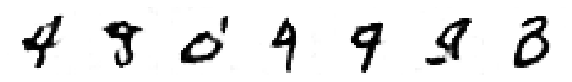

In [20]:
# Load saved weights during training, generate a fake image
netG2 = Generator()
netG2.load_state_dict(torch.load(f'{DBG_FOLDER_GAN}/netG_{EPOCHS-1:d}.pth', weights_only=True))
netG2.to(Device)

draw_generated(netG2)

WGAN Image - clip weight 0.01

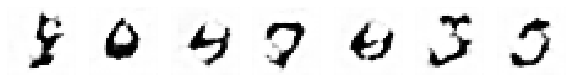

In [26]:
# Load saved weights during training, generate a fake image
netG2 = Generator()
netG2.load_state_dict(torch.load(f'{DBG_FOLDER_WGAN}_clip_weight_001/wgan_netG_{EPOCHS-1:d}.pth', weights_only=True))
netG2.to(Device)

draw_generated(netG2)

WGAN Image - clip weight 0.05

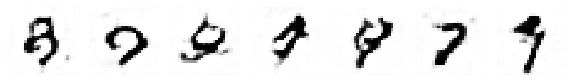

In [ ]:
# Load saved weights during training, generate a fake image
netG2 = Generator()
netG2.load_state_dict(torch.load(f'{DBG_FOLDER_WGAN}_clip_weight_005/wgan_netG_{EPOCHS-1:d}.pth', weights_only=True))
netG2.to(Device)

draw_generated(netG2)

WGAN Image - clip weight 0.10

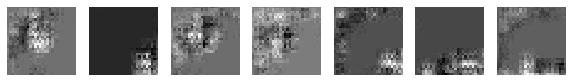

In [29]:
# Load saved weights during training, generate a fake image
netG2 = Generator()
netG2.load_state_dict(torch.load(f'{DBG_FOLDER_WGAN}_clip_weight_010/wgan_netG_{EPOCHS-1:d}.pth', weights_only=True))
netG2.to(Device)

draw_generated(netG2)

In [36]:
def plot_error(_lsDreal, _lsDfake, _lsG):
    # plot the error, skip first error due to large difference, initial condition
    plt.figure(figsize=(8, 6))
    x = [_ for _ in range(len(_lsDreal[1:]))]
    y1_dr, y2_dr = np.array([_[0] for _ in _lsDreal[1:]]), np.array([_[1] for _ in _lsDreal[1:]])
    y1_df, y2_df = np.array([_[0] for _ in _lsDfake[1:]]), np.array([_[1] for _ in _lsDfake[1:]])
    y1_g, y2_g = np.array([_[0] for _ in _lsG[1:]]), np.array([_[1] for _ in _lsG[1:]])
    plt.plot(y1_dr, label='Dis Real', c='darkorchid')
    plt.fill_between(x, y1_dr-y2_dr, y1_dr+y2_dr, color='darkorchid', alpha=0.1)
    plt.plot(y1_df, label='Dis Fake', c='deepskyblue')
    plt.fill_between(x, y1_df-y2_df, y1_df+y2_df, color='deepskyblue', alpha=0.1)
    plt.plot(y1_g, label='Gen', c='coral')
    plt.fill_between(x, y1_g-y2_g, y1_g+y2_g, color='coral', alpha=0.1)
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.grid(axis='y')
    plt.legend()
    plt.show()

GAN convergence plot

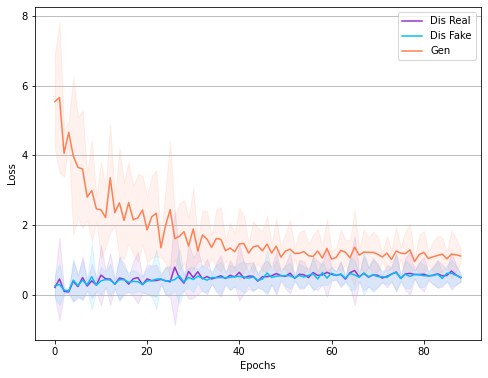

In [37]:
plot_error(gan.LossDReal, gan.LossDFake, gan.LossG)

WGAN Convergence Plot - clip weight 0.05

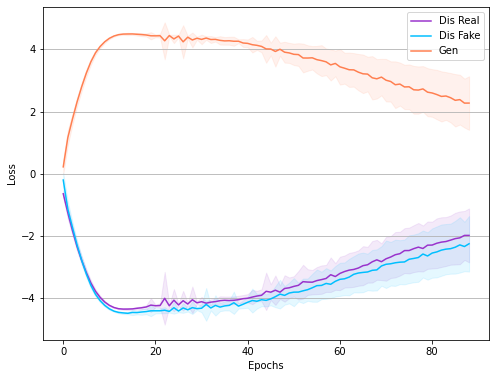

In [38]:
plot_error(wgan.LossDReal, wgan.LossDFake, wgan.LossG)

The WGAN loss becomes negative and evolves more smoothly than the GAN loss because it is estimating the Wasserstein distance rather than the classification-based GAN.

WGAN Convergence Plot - clip weight 0.10


![WGAN Loss Clip Weight 0.10](loss010.png)

Here, we see the large clip value dominating which is preventing convergence.


## Problem 3

The standard GAN images are fairly sharp and crisp with recognizable numbers. There's some fuzziness, but overall it's fairly clean.

The WGAN with clip value 0.01 has digits which are noticeably blurrier and the edges look washed out. There's less contrast and the digits look off or partially formed. Many of the digits are hard to recognize. The small weight clipping is likely constraining the critic so not as much progress is made.

The WGAN with clip value 0.05 is much improved over 0.01 with sharper strokes. It's still not quite as crisp as the vanilla GAN, but it's closer supporting the idea that the small clip value was constraining the critic.

The WGAN with clip value 0.10 is clearly not stable as we see in the convergence plot.

The digits generated by the WGAN with clip values 0.01 and 0.05 are meaningful in that they are largely recognizable as MNIST digits. With clip value 0.10 the output is not meaningful.

